# Movie Trailer Analysis

## Load Files and API Keys
In order to run this notebook, collect the appropriate YouTube and IMDb movie IDs. After, click on "Runtime" -> "Run all". First, you will allow access to your Drive, as requested in the first cell. The next two cells will prompt you to paste in the respective IDs; do that!. From there, simply wait for the analysis to load.


Provide the YouTube trailer's video ID to generate a .CSV file of its comments.

In [28]:
import sys
import os

# Ensure the parent directory is in the Python path
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('config.py'))))

In [47]:
from dotenv import load_dotenv
import config

# Load environment variables from .env file
load_dotenv()
games = config.games

In [30]:
# Insert YouTube video ID
video_id = "fLNQdjg3jC4" 

Insert IMDb Movie ID to discover new insights about user comments in relation to your movie of interest.

In [31]:
# Insert IMDb video ID
# print(f"You entered: {movie_id}")

In [32]:
# !pip -q install transformers openai==0.27.4 xformers emoji tiktoken IMDbPY langdetect

# File Imports
import os
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import pipeline
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
import emoji
import tiktoken
from imdb import IMDb
import spacy
from langdetect import detect
import nltk
import copy
import httplib2
from googleapiclient.discovery import build_from_document
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
import time
from openai import APIConnectionError, RateLimitError, APITimeoutError, NotFoundError, APIError
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from bs4 import BeautifulSoup
from IPython.display import display, Markdown
import io
import openai
import html
import json
import ast
import concurrent.futures
from concurrent.futures import ThreadPoolExecutor
import requests
from openai import OpenAI

nltk.download('stopwords')
pd.options.display.max_colwidth = 100

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/guillaumedherouville/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### YouTube Trailer Comments Download


In [33]:
api_key = os.getenv('YOUTUBE')
http = httplib2.Http()
service_name = 'youtube'
version = 'v3'
discovery_url = f'https://www.googleapis.com/discovery/v1/apis/{service_name}/{version}/rest'
discovery_http = http.request(discovery_url)[1]
youtube_service = build_from_document(discovery_http, developerKey=api_key)

In [34]:
def check_api_key(api_key, video_id="dQw4w9WgXcQ"):  # Using a well-known video ID as default
    url = f"https://www.googleapis.com/youtube/v3/videos?id={video_id}&part=snippet&key={api_key}"
    response = requests.get(url)
    if response.status_code == 200:
        print("API Key is valid!")
        # You can print response.json() to see the details
    else:
        print(f"Failed to validate API Key. Status Code: {response.status_code}")
        print(f"Response: {response.json()}")
check_api_key(api_key)

API Key is valid!


In [35]:
def get_video_comments(service, **kwargs):
    comments = []
    results = service.commentThreads().list(**kwargs).execute()

    with tqdm() as progress_bar:  # create a progress bar

        while results:
            for item in results['items']:
                comment = item['snippet']['topLevelComment']['snippet']['textDisplay']
                comments.append(comment)

            progress_bar.update()  # update progress bar

            if 'nextPageToken' in results:
                kwargs['pageToken'] = results['nextPageToken']
                results = service.commentThreads().list(**kwargs).execute()
            else:
                break

    return comments

# def write_comments_to_csv(comments, filename):
#     df = pd.DataFrame(comments, columns=['comment'])
#     return df

In [36]:
def generate_comments_df(video_id, max_comments=1050):
    comments = []
    next_page_token = None
    while len(comments) < max_comments:
        kwargs = {
            "part": "snippet",
            "videoId": video_id,
            "maxResults": min(100, max_comments - len(comments)),
        }
        if next_page_token:
            kwargs["pageToken"] = next_page_token

        page_comments = get_video_comments(youtube_service, **kwargs)
        comments.extend(page_comments)
        if len(page_comments) < kwargs["maxResults"]:
            break
        if len(comments) >= max_comments:
            break
    df = pd.DataFrame(comments, columns=["comment"])
    return df

In [37]:
# comments = get_video_comments(youtube_service, part='snippet', videoId=video_id)
# filename = f'comments_{video_id}.csv'
# df = write_comments_to_csv(comments, filename)
temp = generate_comments_df(video_id)

6it [00:01,  3.99it/s]
6it [00:01,  5.86it/s]


### Remove NaN and non-English Text
This takes a noticeably long amount of time to run. It is probably more useful to leave junk text in each dataframe, as sentiment / entity analysis will not pick up on it anyways.

In [38]:
temp.dropna(inplace = True)

def detect_lang(text):
  try:
      lang = detect(text)
  except:
      lang = 'unknown'
  return lang

# Apply the function to each row in the dataframe
temp['language'] = temp['comment'].apply(detect_lang)

# Filter out rows that are not in English
temp = temp[temp['language'] == 'en']

# Reset Index
temp = temp.reset_index(drop = True)

In [39]:
temp = temp.iloc[:1000]

In [40]:
# Copy DataFrame
temp_org = temp.copy()

# Randomly choose 3,000 comments
# temp = temp.sample(n=3000).reset_index(drop=True)
temp = temp.reset_index(drop=True)

# Printing first_5
print(temp.head(5))

# Another backup for the sampled dataframe
org = copy.deepcopy(temp)

# Store total amount of comments for later
comment_total = len(temp)

                                                                                               comment  \
0                                                                           Without Catlin game boring   
1                           You need to stop throwing the ball from 3 points without touching the rim,   
2  C Clark what a greatest player to come out of college and played like a pro immediately awesome ...   
3                                                                        There’s a new sheriff in town   
4                 YESSSSSSS, THE INDIANA FEVER WOMAN ARE FINALLY COMING TOGETHER AS A TEAM!!! WOOHOO ❤   

  language  
0       en  
1       en  
2       en  
3       en  
4       en  


In [41]:
# Extract all comments
comments = temp['comment'].tolist()

In [42]:
# Copy DataFrame
temp_org = temp.copy()

# Randomly choose 3,000 comments (this line is commented out in your code)
# temp = temp.sample(n=3000).reset_index(drop=True)

# Reset index of DataFrame
temp_org = temp_org.reset_index(drop=True)

# Extract all comments
comments_t = temp_org['comment'].tolist()

def remove_emojis_and_apostrophes(text):
    # Convert HTML entities to text
    text = html.unescape(text)
    # Convert emojis to text
    text = emoji.demojize(text)
    # Remove HTML anchor tags and their content
    text = re.sub(r'<a\s+href=.*?>.*?</a>', '', text, flags=re.IGNORECASE)
    # Remove apostrophes and double quotes
    text = text.replace("'", "").replace('"', '')
    text = text.replace('“', '').replace('”', '')
    text = text.replace('‘', '').replace('’', '')
    # Remove line breaks if needed.replace('<i>', '')
    text = text.replace('<br>', '').replace('<b>', '').replace('<i>', '').replace('</i>', '').replace('</b>', '')
    return text

# Remove emojis, apostrophes, and other characters from all comments
comments_t = [remove_emojis_and_apostrophes(comment) for comment in comments_t]

# Update the DataFrame with the cleaned comments
temp_org['comment'] = comments_t

# Sentiment Analysis

In [43]:
classifier_1 = pipeline("sentiment-analysis", model='cardiffnlp/twitter-roberta-base-sentiment-latest',  tokenizer='cardiffnlp/twitter-roberta-base-sentiment-latest', return_all_scores=True)
classifier_2 = pipeline("text-classification", model='bhadresh-savani/distilbert-base-uncased-emotion', return_all_scores=True)
tokenizer_kwargs = {'padding':True,'truncation':True,'max_length':500}

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
/opt/homebrew/anaconda3/envs/socialsense/lib/python3.8/site-packages/transformers/pipelines/text_classification.py:104: UserWarning: `retur

In [44]:
# Define a function to get classifier results for a single comment
def get_classifiers_output(comment):
  a = classifier_1(comment, **tokenizer_kwargs)
  b = classifier_2(comment, **tokenizer_kwargs)
  return a, b #, c

In [45]:
with ThreadPoolExecutor() as executor:
    results = list(tqdm(executor.map(get_classifiers_output, comments), total=len(comments)))

# Process the results
all_scores = []
emote = []

for (a, b) in results:
    for l in range(3):
        all_scores.append(a[0][l]['score'])
    for m in range(6):
        all_scores.append(b[0][m]['score'])
    emote.append(b[0])

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [03:54<00:00,  4.26it/s]


In [46]:
# Directly compare
comments_comp = temp[['comment']]
emote_flattened = [{emotion['label']: emotion['score'] for emotion in comment_emotions} for comment_emotions in emote]
emote_df = pd.DataFrame(emote_flattened)
merged_df = pd.concat([comments_comp, emote_df], axis = 1)
merged_df['class'] = merged_df[['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']].idxmax(axis = 1)
merged_df

,comment,sadness,joy,love,anger,fear,surprise,class
0,Without Catlin game boring,0.986922,0.001546,0.000522,0.010077,0.000579,0.000355,sadness
1,"You need to stop throwing the ball from 3 points without touching the rim,",0.015381,0.004439,0.001300,0.219130,0.758029,0.001721,fear
2,C Clark what a greatest player to come out of college and played like a pro immediately awesome ...,0.000530,0.997189,0.000325,0.000423,0.000379,0.001155,joy
3,There’s a new sheriff in town,0.029161,0.797800,0.003457,0.151535,0.014896,0.003151,joy
4,"YESSSSSSS, THE INDIANA FEVER WOMAN ARE FINALLY COMING TOGETHER AS A TEAM!!! WOOHOO ❤",0.001864,0.993326,0.000755,0.002087,0.001369,0.000598,joy
...,...,...,...,...,...,...,...,...
995,0an 11 mystics coach need to be fired I see Ted was at the game out coach again come on you al...,0.884649,0.006395,0.001183,0.105735,0.001152,0.000886,sadness
996,"Once Fever synchs up with CC&#39;s fast paced passing, turnovers will turn into winning more poi...",0.004402,0.976848,0.000995,0.013806,0.002864,0.001083,joy
997,"Wnba,it&#39;s June 7th, not May..it&#39;s okay tho,we here for the highlights ❤",0.001014,0.996584,0.000769,0.000903,0.000439,0.000292,joy
998,CC Teammates on the flr doesn&#39;t even celebrate with her. That says a lot on this team.,0.000465,0.997294,0.001098,0.000700,0.000169,0.000274,joy


## Sentiment, Entity and Emotion Analysis Visualizations and Comparison


This section creates various visuals for the analysis of YouTube comment section.

In [48]:
# Set up table
# Get the mean sentiment for the entire comment section
overall_sentiment = np.mean(np.array(all_scores).reshape(-1, 9), axis=0).tolist()

overall_sentiment_df = pd.DataFrame(overall_sentiment)
overall_sentiment_df = overall_sentiment_df.transpose()
overall_sentiment_df.columns = ['negative', 'neutral', 'positive', 'sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
overall_sentiment_df = overall_sentiment_df.applymap(lambda x: f"{x*100:.1f}%")

# ia = IMDb()
# movie = ia.get_movie(movie_id)

new_rows = pd.DataFrame(games)
titles = ['Indiana Fever vs. Washington Mystics', 'Phoenix Mercury vs. Indiana Fever', 'Connecticut Sun vs. Indiana Fever', 'Las Vegas Aces vs. Indiana Fever', 'Indiana Fever vs. Atlanta Dream', 'Chicago Sky vs. Indiana Fever']
overall_sentiment_df = pd.concat([overall_sentiment_df, new_rows], axis = 0).reset_index(drop=True)
overall_sentiment_df.insert(0, 'Title', titles)

overall_sentiment_df

,Title,negative,neutral,positive,sadness,joy,love,anger,fear,surprise
0,Indiana Fever vs. Washington Mystics,24.0%,32.6%,43.4%,7.9%,54.3%,1.8%,26.7%,7.5%,1.9%
1,Phoenix Mercury vs. Indiana Fever,30.2%,29.3%,40.5%,10.3%,46.9%,2.3%,30.4%,8.3%,1.8%
2,Connecticut Sun vs. Indiana Fever,48.6%,32.5%,18.9%,16.1%,34.9%,1.4%,37.1%,9.2%,1.4%
3,Las Vegas Aces vs. Indiana Fever,37.2%,32.5%,30.3%,12.5%,49.8%,1.3%,28.5%,6.8%,1.0%
4,Indiana Fever vs. Atlanta Dream,25.2%,27.2%,47.6%,8.6%,57.2%,2.3%,23.8%,7.5%,0.7%
5,Chicago Sky vs. Indiana Fever,14.8%,29.0%,56.2%,7.2%,57.0%,2.1%,23.1%,8.5%,2.1%


/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_82888/1606053060.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_df[col] = sentiment_df[col].apply(percent_to_float)
/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_82888/1606053060.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sentiment_df[col] = sentiment_df[col].apply(percent_to_float)
/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_82888/1606053060.py:12: SettingWithCopyWarning: 
A value is trying to b

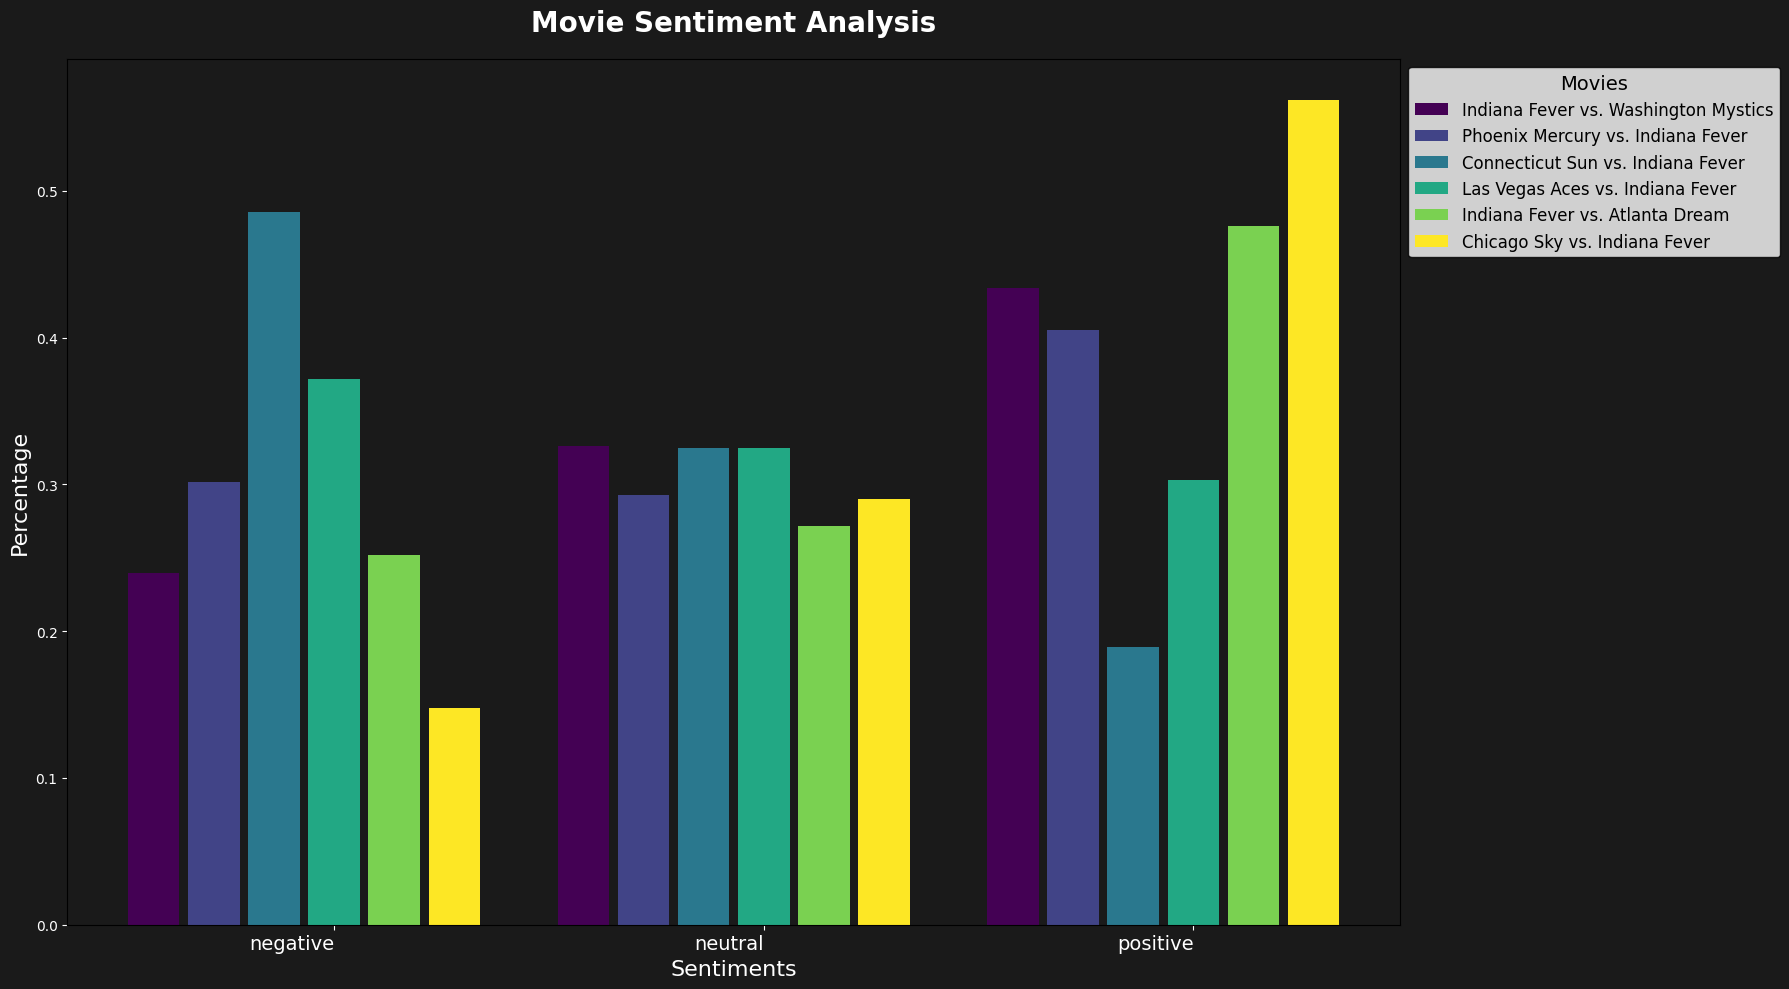

/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_82888/1606053060.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emotion_df[col] = emotion_df[col].apply(percent_to_float)
/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_82888/1606053060.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  emotion_df[col] = emotion_df[col].apply(percent_to_float)
/var/folders/jm/2zytm77j0ms47q8tymwmv8800000gn/T/ipykernel_82888/1606053060.py:63: SettingWithCopyWarning: 
A value is trying to be set on

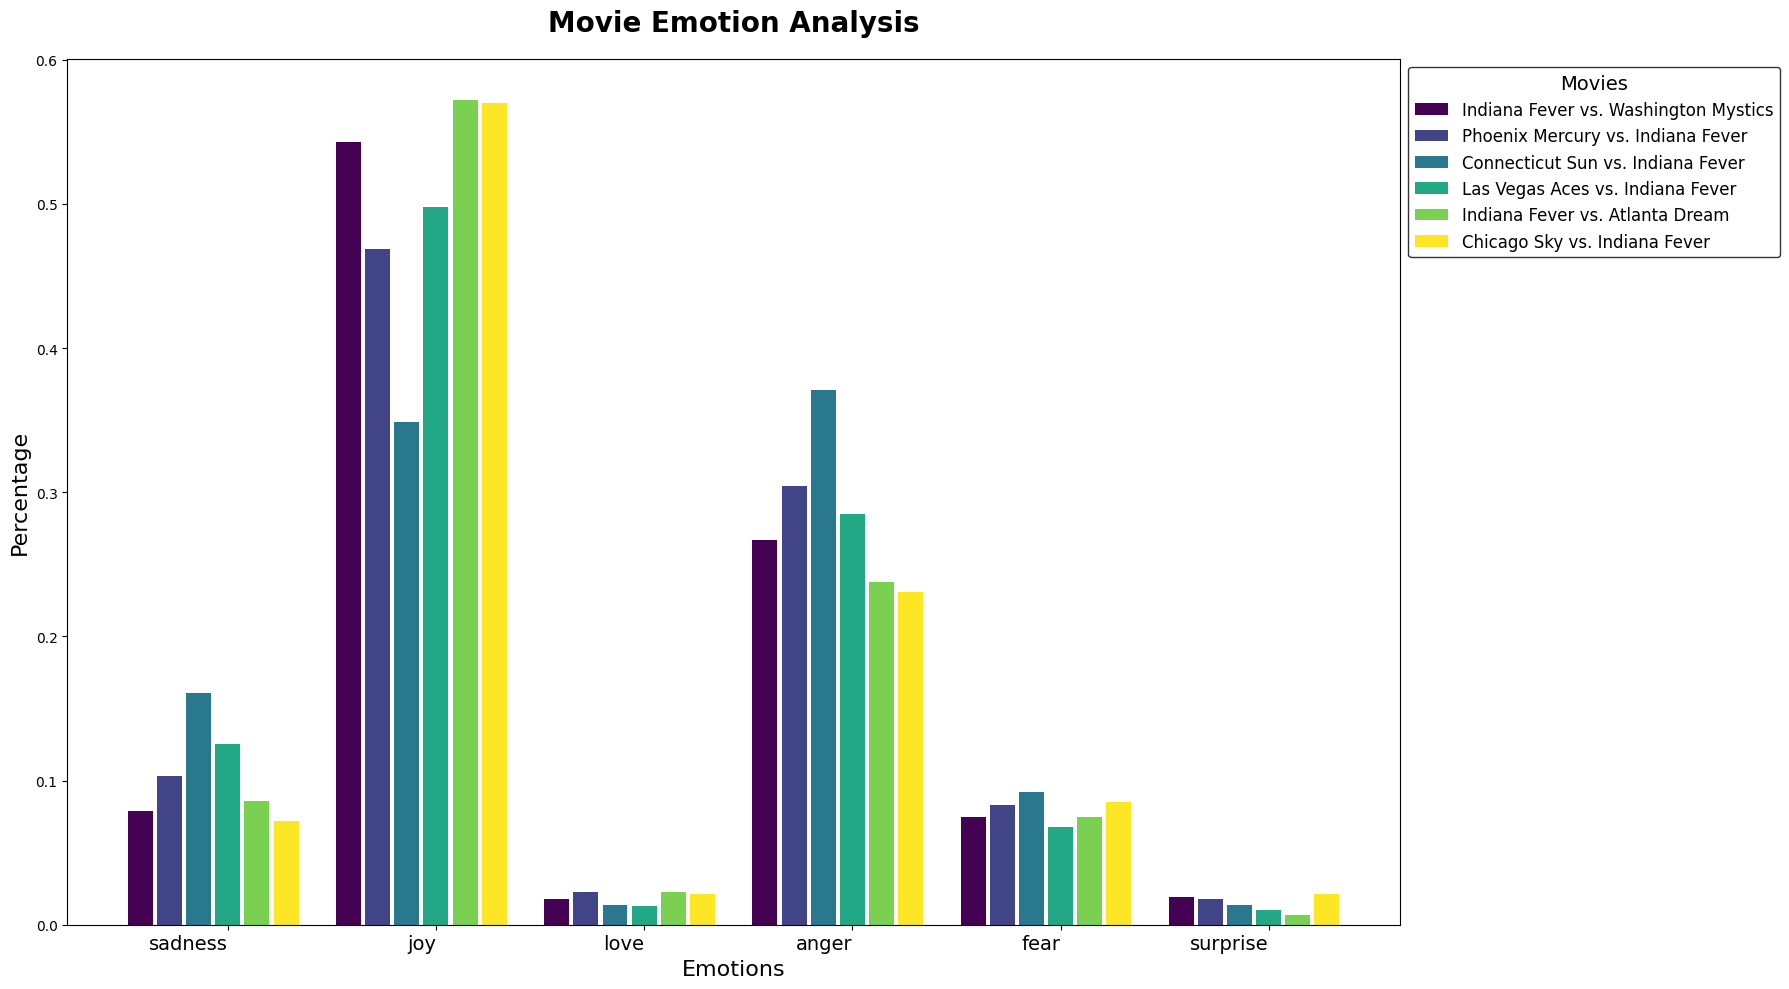

In [49]:
import matplotlib.pyplot as plt

sentiment_df = overall_sentiment_df[['Title', 'negative', 'neutral', 'positive']]
emotion_df = overall_sentiment_df[['Title', 'sadness', 'joy', 'love', 'anger', 'fear', 'surprise']]

# Convert percentages back to float for plotting
def percent_to_float(s):
    return float(s.strip('%'))/100

# Convert the string percentage columns back to floats
for col in sentiment_df.columns[1:]:
    sentiment_df[col] = sentiment_df[col].apply(percent_to_float)

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(18, 10))  # Increase the width to widen the x-axis
plt.gcf().set_facecolor('.1')  # Set the background of the figure
ax.set_facecolor('.1')  # Set the background of the axes

# Number of movies
n_movies = len(sentiment_df['Title'])
width = 0.12  # Adjust width of the bars
spacing = 0.02  # Space between bars

# Generate positions of the bars
positions = list(range(n_movies))

colors = plt.cm.viridis(np.linspace(0, 1, n_movies))

for idx, movie in enumerate(sentiment_df['Title']):
    plt.bar(
        [p + idx * (width + spacing) for p in range(len(sentiment_df.columns[1:]))],
        sentiment_df.loc[idx, sentiment_df.columns[1:]],
        width=width,
        label=movie,
        color=colors[idx]
    )

# Adjust the x-ticks and labels
ax.set_xticks([p + (width + spacing) * n_movies / 2 for p in range(len(sentiment_df.columns[1:]))])
ax.set_xticklabels(sentiment_df.columns[1:], fontsize=14)
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# Add legend
legend = plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1, fontsize=12)
legend.set_title('Movies', prop={'size': 14})  # Set legend title
legend.get_frame().set_facecolor('white')  # Set legend background color
legend.get_frame().set_edgecolor('black')

# Rotate x labels for better visibility
plt.setp(ax.get_xticklabels(), rotation=0, horizontalalignment='right')

# Enhance the title and labels
ax.set_title('Movie Sentiment Analysis', fontsize=20, fontweight='bold', pad=20, color = "white")
ax.set_xlabel('Sentiments', fontsize=16, color = "white")
ax.set_ylabel('Percentage', fontsize=16, color = "white")

plt.tight_layout()
plt.show()

# Convert the string percentage columns back to floats
for col in emotion_df.columns[1:]:
    emotion_df[col] = emotion_df[col].apply(percent_to_float)

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(18, 10))  # Increase the width to widen the x-axis

# Number of movies
n_movies = len(emotion_df['Title'])
width = 0.12  # Adjust width of the bars
spacing = 0.02  # Space between bars

# Generate positions of the bars
positions = list(range(n_movies))

colors = plt.cm.viridis(np.linspace(0, 1, n_movies))

for idx, movie in enumerate(emotion_df['Title']):
    plt.bar(
        [p + idx * (width + spacing) for p in range(len(emotion_df.columns[1:]))],
        emotion_df.loc[idx, emotion_df.columns[1:]],
        width=width,
        label=movie,
        color=colors[idx]
    )

# Adjust the x-ticks and labels
ax.set_xticks([p + (width + spacing) * n_movies / 2 for p in range(len(emotion_df.columns[1:]))])
ax.set_xticklabels(emotion_df.columns[1:], fontsize=14)

# Add legend
legend = plt.legend(loc='upper left', bbox_to_anchor=(1,1), ncol=1, fontsize=12)
legend.set_title('Movies', prop={'size': 14})  # Set legend title
legend.get_frame().set_facecolor('white')  # Set legend background color
legend.get_frame().set_edgecolor('black')

# Rotate x labels for better visibility
plt.setp(ax.get_xticklabels(), rotation=0, horizontalalignment='right')

# Enhance the title and labels
ax.set_title('Movie Emotion Analysis', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Emotions', fontsize=16)
ax.set_ylabel('Percentage', fontsize=16)

plt.tight_layout()
plt.show()

# Topic Modeling

In [50]:
openai.api_key

'sk-social-sense-colab-notebook-Wij5esdHOwiD4nuPRJzmT3BlbkFJbgOPct4m1oEnZmqtD9X7'

In [51]:
# Key
openai.api_key = os.getenv("OPENAI")
key = os.getenv("OPENAI")

In [52]:
encoding = tiktoken.encoding_for_model("gpt-4o")
def num_tokens_from_string(string: str) -> int:
    """Returns the number of tokens in a text string."""
    num_tokens = len(encoding.encode(string))
    return num_tokens

def chunkify_by_tokens(text, max_tokens):
    words = text.split()
    chunks = []
    chunk = []
    chunk_tokens = 0

    for word in words:
        word_tokens = num_tokens_from_string(word)

        if chunk_tokens + word_tokens <= max_tokens:
            chunk.append(word)
            chunk_tokens += word_tokens
        else:
            chunks.append(' '.join(chunk))
            chunk = [word]
            chunk_tokens = word_tokens

        # Add the last chunk if it's not empty
        if chunk:
            chunks.append(' '.join(chunk))

        return chunks

class ChatGPT:
    def __init__(self, model="gpt-4o", system_message=None):
        self.client = OpenAI(api_key=openai.api_key)
        self.model = model
        if system_message:
            self.default_system_message = {"role": "system", "content" : system_message}
        else:
            self.default_system_message = {"role": "system", "content" : "Hello! You are the SportsCommentBot. You can answer questions about sport and fans reactions to games"}
        self.messages = [self.default_system_message]
    def reset_history(self):
        self.messages = [self.default_system_message]

    def add_system_message(self, message, reset_chat=False):
        if reset_chat:
            self.messages = [self.default_system_message]

        self.messages.append({"role": "system", "content": message})

    def add_user_message(self, message, reset_chat=False):
        if reset_chat:
            self.messages = [self.default_system_message]
        self.messages.append({"role": "user", "content": message})

    def get_response(self):
        response = None
        retries = 0
        while response is None and retries < 6:
            try:
                    response = self.send_chat_request()
            except (APIConnectionError, RateLimitError, APITimeoutError, NotFoundError, APIError, openai.BadRequestError, openai.AuthenticationError, openai.ConflictError, openai.InternalServerError, openai.NotFoundError, openai.PermissionDeniedError, openai.UnprocessableEntityError) as e:
                    print(f"Error: {e}")
                    time.sleep(60)  # Wait for 1 minute before retrying
                    retries += 1

        if response is None:
            # If all retries failed, escalate the delay time
            time.sleep(2 ** retries)
        return self.process_response(response)

    def send_chat_request(self):
        response = self.client.chat.completions.create(
            model=self.model,
            messages=self.messages
        )
        return response
    def process_response(self, response):
        # Add the assistant's message to the messages list
        assistant_message = response.choices[0].message.content
        self.messages.append({"role": "assistant", "content": assistant_message})
        return assistant_message


In [53]:
def TOTAL_SUMMARIZER(texts, token_threshold):
    text = '\n'.join(texts)
    chunks = chunkify_by_tokens(text, token_threshold)

    first_pass_summaries = []

    for ci, chunk in enumerate(chunks):
        summarize_prompt = f'Please summarize the following set of comments: \
                            \n\n### COMMENT TEXT\n{chunk}\n\n### BEGIN RESPONSE\n'
        try:
            chat = ChatGPT(system_message="You are an expert text summarizer and analyzer.")
            chat.add_user_message(summarize_prompt)
            summarized_chunk = chat.get_response()            
            first_pass_summaries.append(summarized_chunk)

        except (APIConnectionError, RateLimitError, APITimeoutError, NotFoundError, APIError, openai.BadRequestError, openai.AuthenticationError, openai.ConflictError, openai.InternalServerError, openai.NotFoundError, openai.PermissionDeniedError, openai.UnprocessableEntityError) as e:
            print(f"Error during initial summarization: {e}")
            # Continue to next chunk instead of returning
            continue

    candidate_text = '\n'.join(first_pass_summaries)

    iterations = 0
    candidate_len = np.inf

    while candidate_len > token_threshold:
        iterations += 1
        chunks = chunkify_by_tokens(candidate_text, token_threshold)

        summarized_chunks = []
        for chunk in chunks:
            try:
                chat = ChatGPT(system_message="You are an expert text summarizer and analyzer. You are recursively summarizing topics expressed by consumers to select the most commonly expressed topics.")
                summarize_prompt = f"This is a summarization of comments regarding a WNBA game. \
                                    List the top 5 most prominent positive aspects of the game that commenters like and want to see more of.\
                                    List the top 5 most prominent negative aspects of the game that commenters dislike and/or might cause them to not watch similar games.\
                                    Be specific in your generation of topics, and ensure that each topic is distinct. \
                                    \n### TEXT\n{chunk}\n\n### BEGIN RESPONSE\n"
                chat.add_user_message(summarize_prompt)
                summarized_chunk = chat.get_response()
                # Verify and process the summarized chunk here if necessary
                # summarized_chunks.append(summarized_chunk)
            except Exception as e:
                print(f"Error during iterative summarization: {e}")
                # Optionally handle the error, like retrying summarization for this chunk
                continue

        candidate_text = ' '.join(summarized_chunks)
        candidate_len = num_tokens_from_string(candidate_text)

    try:
        chat = ChatGPT(system_message="You are an expert text summarizer and analyzer for a sports media company. \
                                    You will select the most common topics expressed by spectators regarding a WNBA game.")
        summarize_prompt = f"""This is a summarization of comments regarding a WNBA game. \
                            First, list the top 5 most prominent positive aspects of the game that commenters like and want to see more of.\
                            Next, list the top 5 most prominent negative aspects of the game that commenters dislike and/or might cause them to not watch similar games.\
                            Please place them in a single list separated by numbers (ex. 1. Theme 1 \n 2. Theme 2 \n etc.) and nothing else \
                            (for example, do not separate into positive and negative groupings. Rather express how they are positive and negative in the themes themseleves) \
                            Also, DO NOT use any apostrophes (') in your response. \
                            In your generation, allow for the topics to be mutually exclusive and collectively exhaustive; each topic should be unique, but all the topics together should comprise the most prominent ideas expressed.\
                            Do not generate more than the 5 positive topics, followed by the 5 negative topics, for a total of 10 topics separeted by one space each.
                            \n### TEXT\n{candidate_text}\n\n### BEGIN RESPONSE\n"""
        chat.add_user_message(summarize_prompt)
        final_response = chat.get_response()
        # Verify and process the summarized chunk here if necessary
    except Exception as e:
        print(f"Error during iterative summarization: {e}")
        # Optionally handle the error, like retrying summarization for this chunk
        return candidate_text

    return final_response

In [54]:
# Your function to get summarized results
to_summarize_2000 = temp_org['comment'].astype(str).tolist()
all_resp = TOTAL_SUMMARIZER(to_summarize_2000, 3900)
resp_list = all_resp.splitlines()

In [55]:
# Display results
if all_resp:
    display(Markdown('### Summarized Output'))
    display(Markdown('Below is the output from chunking the text and recursively querying OpenAI to summarize the comments:'))
    display(Markdown('Aspects of the game that commenters like:'))
    display(Markdown('\n'.join(resp_list[0:5])))
    display(Markdown('Aspects of the game that commenters dislike:'))
    display(Markdown('\n'.join(resp_list[5:10])))
else:
    display(Markdown('**No output received from BASELINE_SUMMARIZER.**'))

### Summarized Output

Below is the output from chunking the text and recursively querying OpenAI to summarize the comments:

Aspects of the game that commenters like:

1. Enthusiasm about player performance 
2. Appreciation for team strategy and gameplay 
3. Excitement over close score and competitive spirit 
4. Recognition of standout moments and highlights 
5. Positive commentary on sportsmanship and teamwork 

Aspects of the game that commenters dislike:

6. Concerns about officiating and refereeing 
7. Disappointment with low attendance 
8. Frustration over broadcasting quality 
9. Criticism of coaching decisions 
10. Complaints about game scheduling and timing